In [1]:
print("Supreme")

Supreme


In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
from scipy.stats import skew
from sklearn.preprocessing import PowerTransformer , StandardScaler , LabelEncoder 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix , f1_score


In [3]:
# Models 

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier , ExtraTreesClassifier , BaggingClassifier 
from sklearn.svm import SVC 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier 


In [4]:
# loading of dataset 

df=pd.read_csv("predictive_maintenance.csv")
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,5402,M20261,M,302.6,312.3,1454,54.8,253,1
1,5401,L52580,L,302.7,312.4,1477,46.3,251,1
2,5400,H34813,H,302.8,312.4,1411,53.8,246,1
3,2865,H32278,H,300.6,309.4,1380,47.6,246,1
4,9672,L56851,L,299.0,310.2,1412,44.1,246,0
...,...,...,...,...,...,...,...,...,...
9995,1597,L48776,L,298.0,308.1,1877,24.3,0,0
9996,3028,L50207,L,300.5,309.5,1777,23.6,0,0
9997,4648,L51827,L,303.3,311.4,1958,21.5,0,0
9998,419,L47598,L,297.4,308.4,2151,17.7,0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 771.6 KB


In [6]:
df.dtypes

UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Target                       int64
dtype: object

In [7]:
df.isna().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
# removal of variable which is not required for analysis
df = df.drop(['UDI', 'Product ID'], axis=1)
df


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,M,302.6,312.3,1454,54.8,253,1
1,L,302.7,312.4,1477,46.3,251,1
2,H,302.8,312.4,1411,53.8,246,1
3,H,300.6,309.4,1380,47.6,246,1
4,L,299.0,310.2,1412,44.1,246,0
...,...,...,...,...,...,...,...
9995,L,298.0,308.1,1877,24.3,0,0
9996,L,300.5,309.5,1777,23.6,0,0
9997,L,303.3,311.4,1958,21.5,0,0
9998,L,297.4,308.4,2151,17.7,0,0


In [10]:
df.columns = df.columns.str.strip().str.replace(" ", "").str.replace("[", "").str.replace("]", "").str.replace("/", "").str.lower()


In [12]:
# Data Preprocessing
# conversion of categorical variable into numerical variable
df = pd.get_dummies(df, columns=['type'], drop_first=True, dtype=int)
df
df

,airtemperaturek,processtemperaturek,rotationalspeedrpm,torquenm,toolwearmin,target,type_L,type_M
0,302.6,312.3,1454,54.8,253,1,0,1
1,302.7,312.4,1477,46.3,251,1,1,0
2,302.8,312.4,1411,53.8,246,1,0,0
3,300.6,309.4,1380,47.6,246,1,0,0
4,299.0,310.2,1412,44.1,246,0,1,0
...,...,...,...,...,...,...,...,...
9995,298.0,308.1,1877,24.3,0,0,1,0
9996,300.5,309.5,1777,23.6,0,0,1,0
9997,303.3,311.4,1958,21.5,0,0,1,0
9998,297.4,308.4,2151,17.7,0,0,1,0


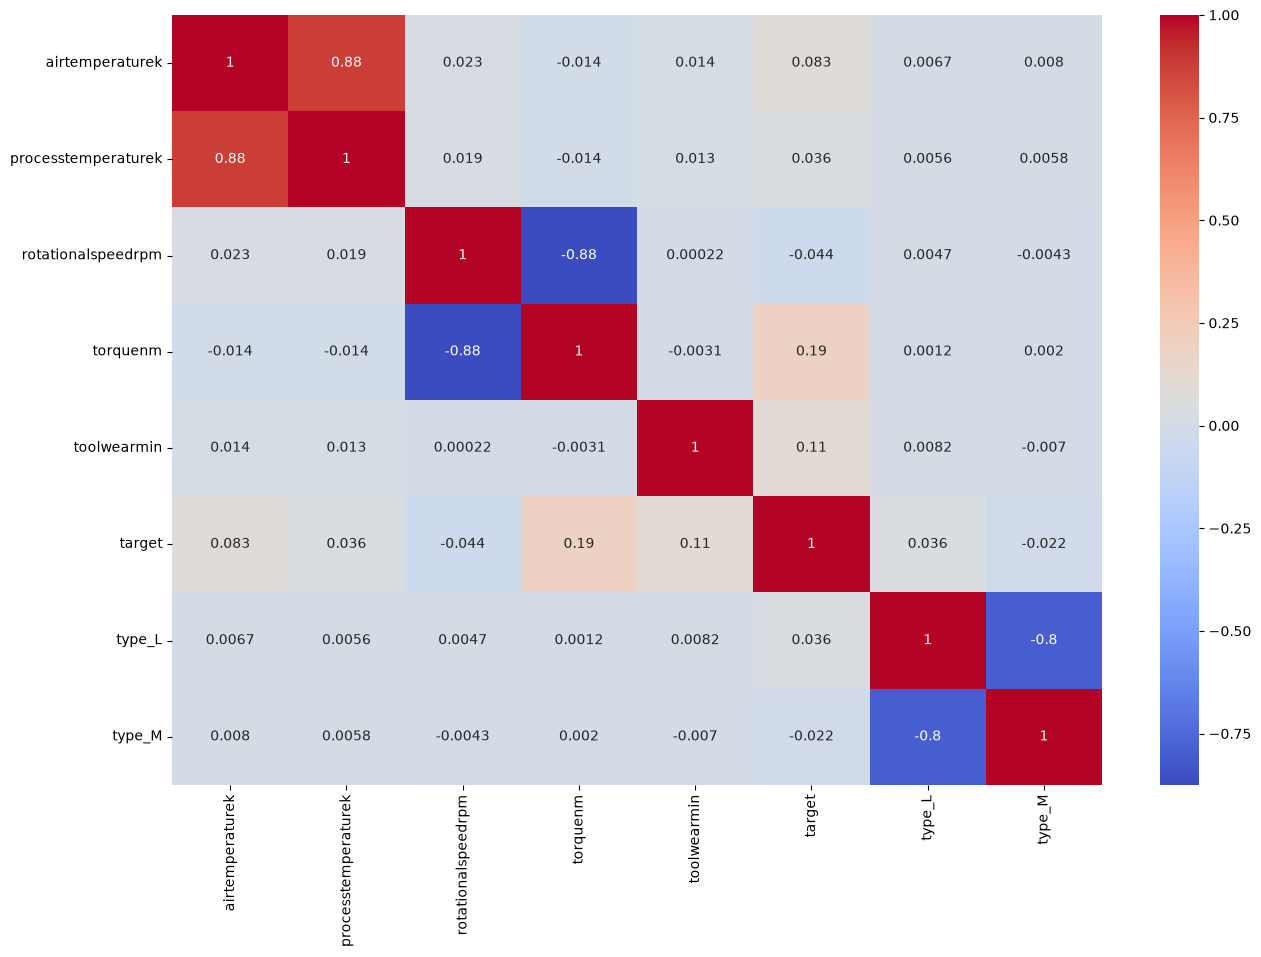

In [13]:
# visualization of correlation between variables
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

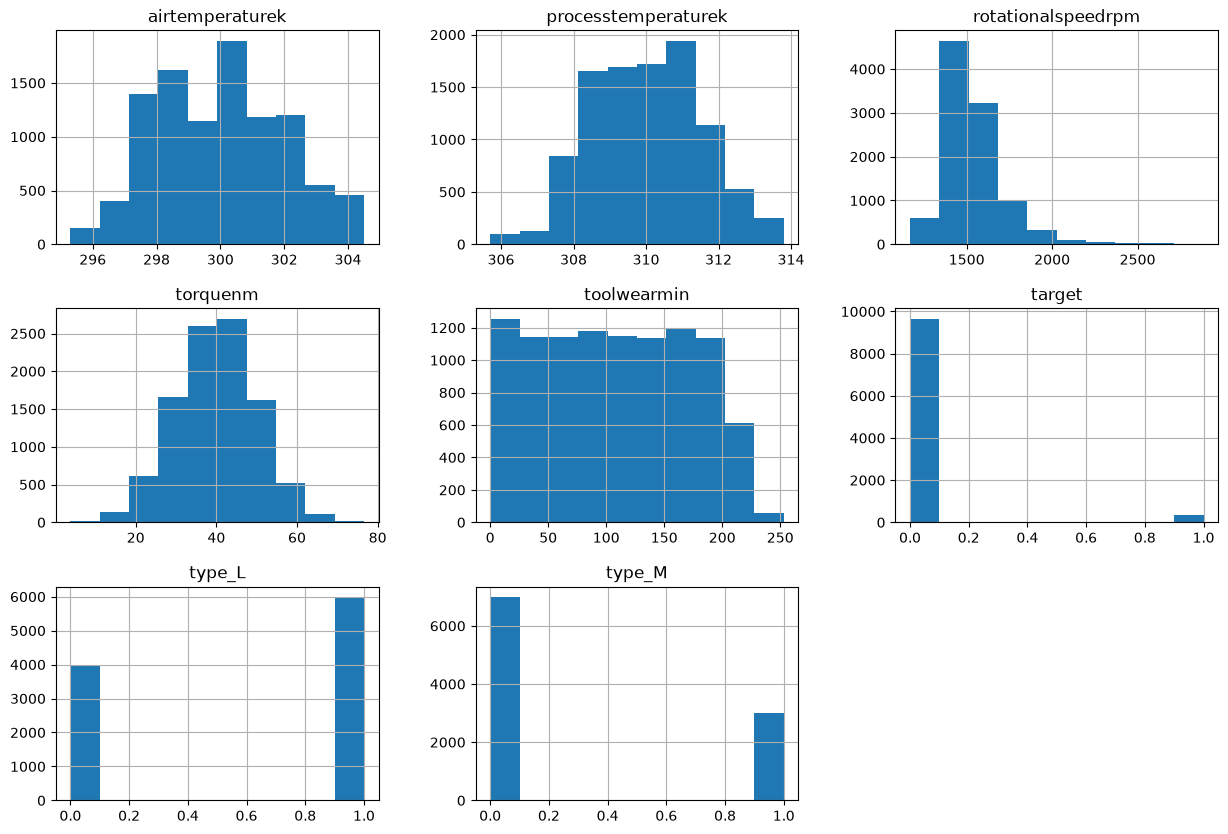

In [14]:
# distributionof variables
df.hist(figsize=(15,10))
plt.show()

In [15]:
# skewness checking of variables and visualization of variables
skewness = df.skew()
skewness.sort_values(ascending=False)


target                 5.151852
rotationalspeedrpm     1.993171
type_M                 0.874562
airtemperaturek        0.114274
toolwearmin            0.027292
processtemperaturek    0.015027
torquenm              -0.009517
type_L                -0.408310
dtype: float64

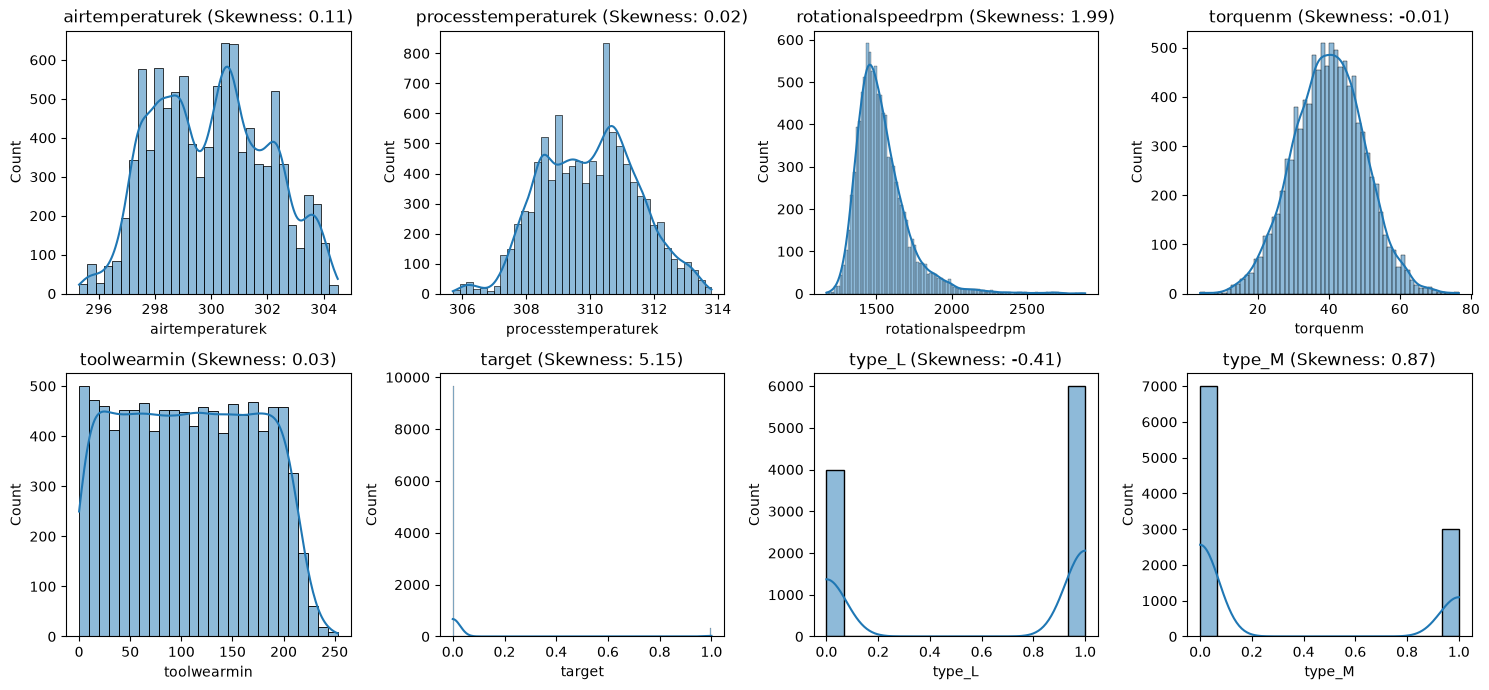

In [16]:
# visualization for skewness distribution of each variable separately
plt.figure(figsize=(15,10))
for i, (var, skew) in enumerate(skewness.items()):
    plt.subplot(3, 4, i + 1)
    sns.histplot(df[var], kde=True)
    plt.title(f'{var} (Skewness: {skew:.2f})')
plt.tight_layout()  
plt.show()


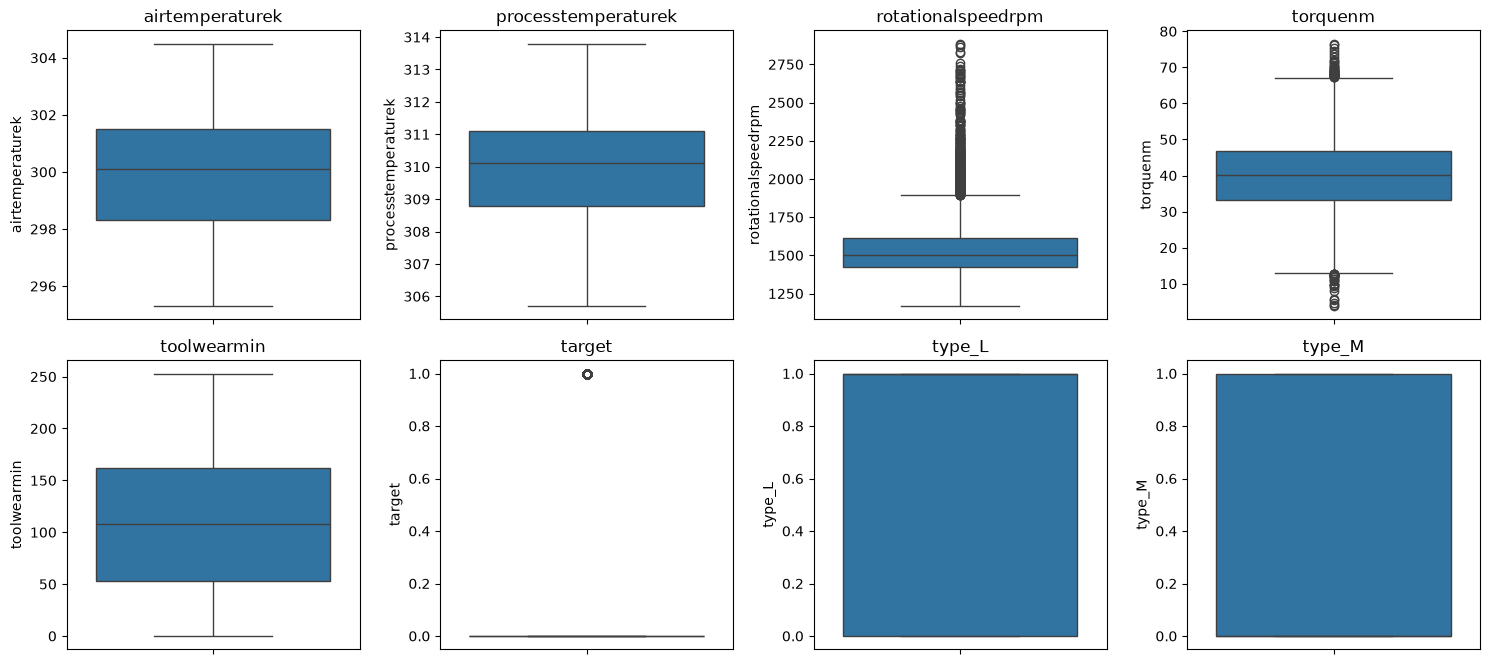

In [17]:
# outlier checking and visualization of each variable separately
plt.figure(figsize=(15,10))
for i, var in enumerate(df.columns):
    plt.subplot(3, 4, i + 1)
    sns.boxplot(df[var])
    plt.title(f'{var}')
plt.tight_layout()
plt.show()

In [20]:
# skewness treatment using PowerTransformer with Yeo-Johnson method without standardization
pt = PowerTransformer(method='yeo-johnson', standardize=False)
df_transformed = pt.fit_transform(df.drop('target', axis=1))
# creating a new DataFrame with transformed features
df_transformed = pd.DataFrame(df_transformed, columns=df.drop('target', axis=1).columns)
df_transformed

,airtemperaturek,processtemperaturek,rotationalspeedrpm,torquenm,toolwearmin,type_L,type_M
0,0.130021,2.373043,0.315954,56.001247,66.466672,0.000000,0.241115
1,0.130021,2.373080,0.315954,47.263461,66.093878,1.364391,0.000000
2,0.130021,2.373080,0.315954,54.972758,65.157939,0.000000,0.000000
3,0.130021,2.371942,0.315954,48.599161,65.157939,0.000000,0.000000
4,0.130021,2.372247,0.315954,45.003634,65.157939,1.364391,0.000000
...,...,...,...,...,...,...,...
9995,0.130021,2.371444,0.315954,24.705764,0.000000,1.364391,0.000000
9996,0.130021,2.371980,0.315954,23.989822,0.000000,1.364391,0.000000
9997,0.130021,2.372702,0.315954,21.842870,0.000000,1.364391,0.000000
9998,0.130021,2.371559,0.315954,17.961575,0.000000,1.364391,0.000000


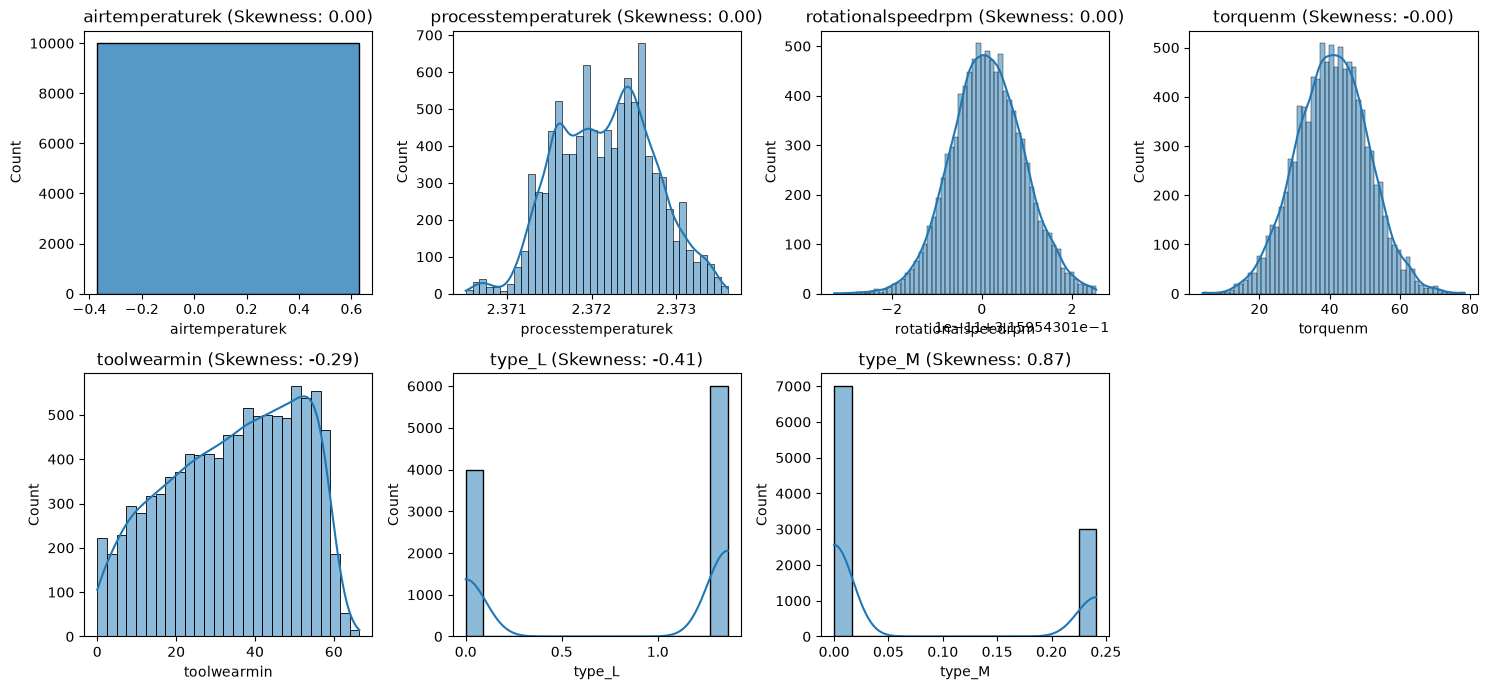

In [21]:
# visualisation after skewness treatment for each variable separately
plt.figure(figsize=(15,10))
for i, var in enumerate(df_transformed.columns):
    plt.subplot(3, 4, i + 1)
    data = df_transformed[var].dropna()
    if data.nunique() > 1:
        sns.histplot(data, kde=True)
    else:
        sns.histplot(data, kde=False)
    plt.title(f'{var} (Skewness: {data.skew():.2f})')
plt.tight_layout()
plt.show()

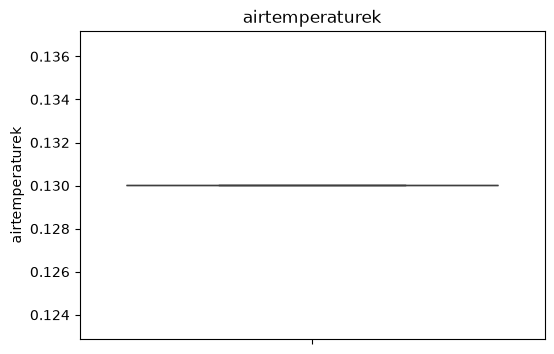

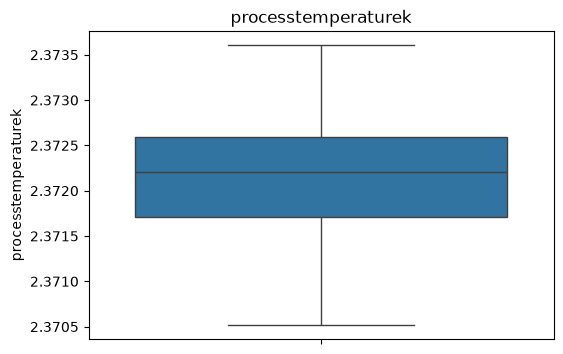

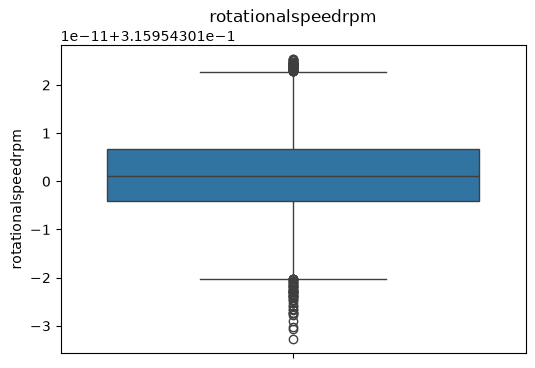

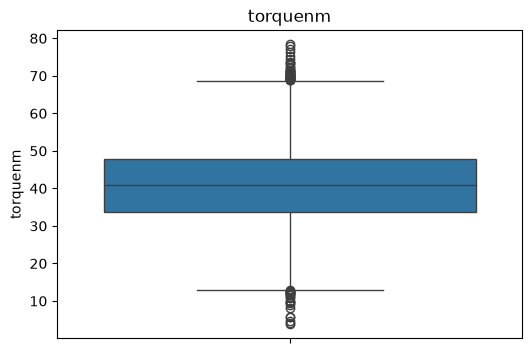

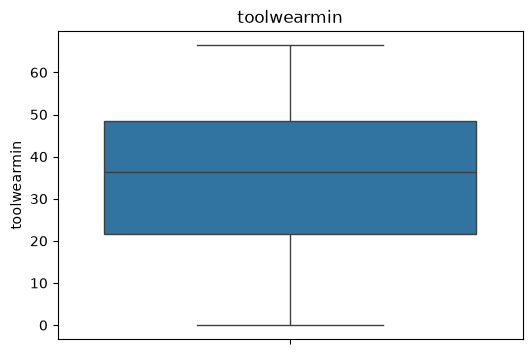

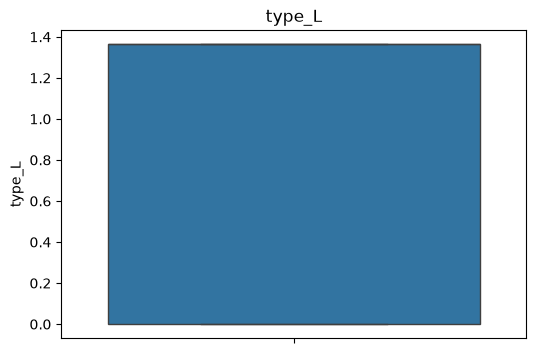

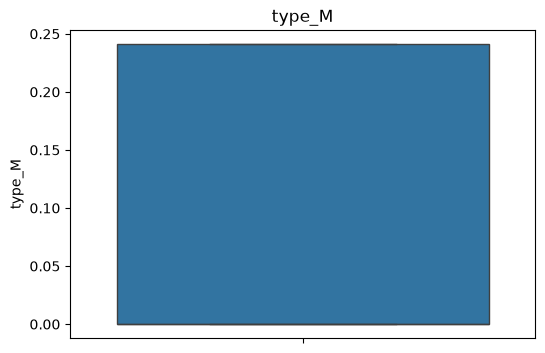

In [22]:
# outlier visualization after skewness treatment for each variable separately
for i, var in enumerate(df_transformed.columns):
    plt.figure(figsize=(6, 4))
    sns.boxplot(df_transformed[var])
    plt.title(f'{var}')
    plt.show()

In [23]:
# outlier treatment using IQR method by capping the outliers to the upper and lower bounds

for i, var in enumerate(df_transformed.columns):
    Q1 = df_transformed[var].quantile(0.25)
    Q3 = df_transformed[var].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    if df_transformed[var].nunique() > 1:
        df_transformed[var] = np.where(df_transformed[var] < lower_bound, lower_bound, df_transformed[var])
        df_transformed[var] = np.where(df_transformed[var] > upper_bound, upper_bound, df_transformed[var])
        
        

    

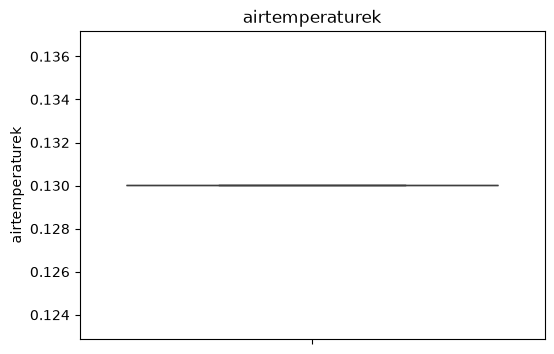

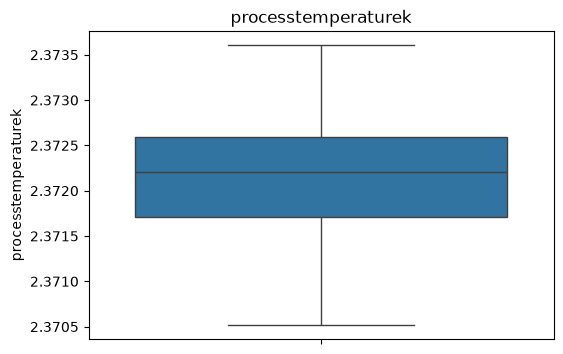

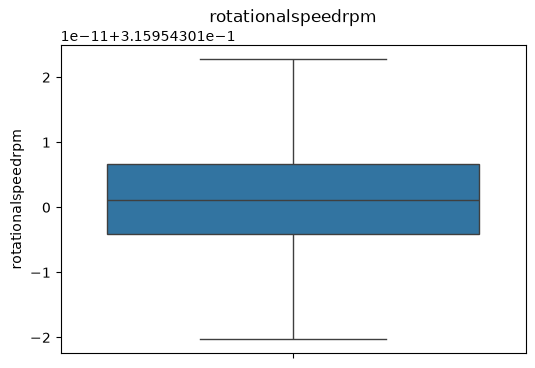

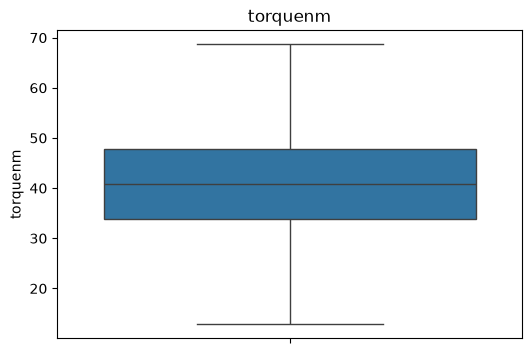

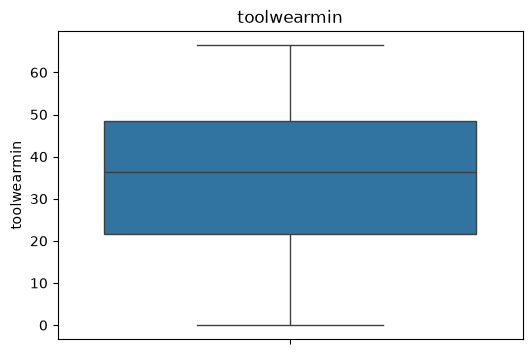

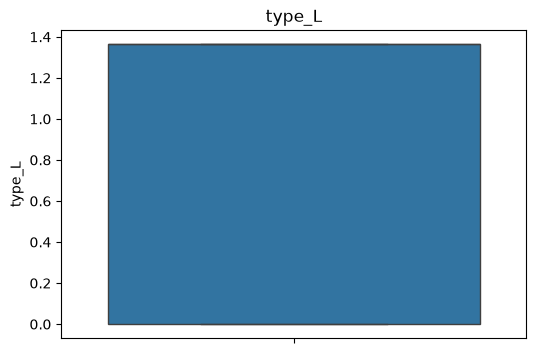

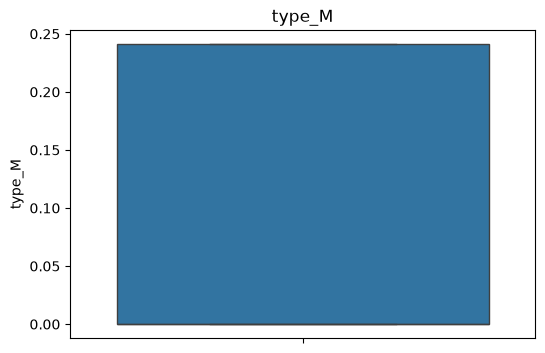

In [24]:
# visualisation after outlier removal for each variable separately
for i, var in enumerate(df_transformed.columns):
    plt.figure(figsize=(6, 4))
    sns.boxplot(df_transformed[var])
    plt.title(f'{var}')
    plt.show()

In [25]:
df_transformed['target'] = df['target']


In [26]:
# splitting of dataset into independent and dependent variable
X = df_transformed.drop('target', axis=1)
y = df_transformed['target']

In [27]:
# splitting into training and testing dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (8000, 7)
Testing set size: (2000, 7)


In [28]:
# check for class imbalance in the target variable
class_counts = y.value_counts()
print("Class counts:")
print(class_counts)

Class counts:
target
0    9661
1     339
Name: count, dtype: int64


In [29]:
# model training first without class balancing
# models to be trained
models = {
    "Logistic Regression": LogisticRegression(),
    "DecisionTreeClassifier": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "Ensemble Bagging": BaggingClassifier(),
    "Ensemble Extra Trees": ExtraTreesClassifier(),
    "Ensemble Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier()}

    

In [30]:

# model building for all the models and checking the accuracy score and f1 score for each model for both training and testing dataset
# model building for all the models and checking the accuracy score and f1 score for each model for both training and testing dataset
model_results = {}

X_train = X_train.copy()
X_test = X_test.copy()
valid_feature_names = X_train.columns.str.replace(r'[\[\]<>]', '', regex=True)
X_train.columns = valid_feature_names
X_test.columns = valid_feature_names

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    model_results[model_name] = {
        "Train Accuracy": accuracy_score(y_train, y_pred_train),
        "Test Accuracy": accuracy_score(y_test, y_pred_test),
        "Train F1 Score": f1_score(y_train, y_pred_train, zero_division=0),
        "Test F1 Score": f1_score(y_test, y_pred_test, zero_division=0)
    }

model_results_df = pd.DataFrame(model_results).T
model_results_df


,Train Accuracy,Test Accuracy,Train F1 Score,Test F1 Score
Logistic Regression,0.967125,0.9670,0.057348,0.057143
DecisionTreeClassifier,1.000000,0.9665,1.000000,0.517986
Random Forest,0.999875,0.9780,0.998152,0.560000
SVM,0.966125,0.9660,0.000000,0.000000
Naive Bayes,0.968375,0.9670,0.130584,0.057143
KNN,0.978875,0.9775,0.604215,0.554455
Ensemble Bagging,0.996000,0.9795,0.937255,0.594059
Ensemble Extra Trees,1.000000,0.9765,1.000000,0.525253
Ensemble Gradient Boosting,0.982500,0.9750,0.660194,0.489796
XGBoost,0.993250,0.9760,0.889344,0.538462


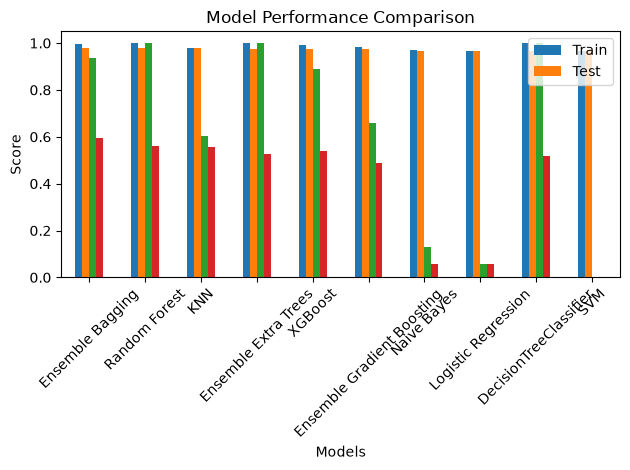

In [31]:
# visualization of model performance for both training and testing dataset in orderwise by best performing model based on test accuracy score
model_results_df = model_results_df.sort_values(by='Test Accuracy', ascending=False)
model_results_df.plot(kind='bar')
plt.title('Model Performance Comparison')
plt.xlabel('Models')
plt.ylabel('Score') 
plt.xticks(rotation=45)
plt.legend(['Train', 'Test'])
plt.tight_layout()
plt.show()

In [32]:
# confusion matrix and classification report for all models for comparison
for model_name, model in models.items():
    y_pred_test = model.predict(X_test)
    print(f"Model: {model_name}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_test))
    print("Classification Report:")
    print(classification_report(y_test, y_pred_test, zero_division=0))
    print("-" * 50)
    

Model: Logistic Regression
Confusion Matrix:
[[1932    0]
 [  66    2]]
Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       1.00      0.03      0.06        68

    accuracy                           0.97      2000
   macro avg       0.98      0.51      0.52      2000
weighted avg       0.97      0.97      0.95      2000

--------------------------------------------------
Model: DecisionTreeClassifier
Confusion Matrix:
[[1897   35]
 [  32   36]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1932
           1       0.51      0.53      0.52        68

    accuracy                           0.97      2000
   macro avg       0.75      0.76      0.75      2000
weighted avg       0.97      0.97      0.97      2000

--------------------------------------------------
Model: Random Forest
Confusion Matrix:
[[1928    4]

In [33]:
# class balancing using SMOTE (Synthetic Minority Over-sampling Technique) to handle class imbalance in the target variable
# install imbalanced-learn library 
!pip install imbalanced-learn

# import smote from imblearn
from imblearn.over_sampling import SMOTE

print("Before SMOTE Class counts:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Balanced Training set size:", X_train_balanced.shape)
print("Balanced Class counts:")
print(y_train_balanced.value_counts())

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
print("Balanced Training set size:", X_train_balanced.shape)
print("Balanced Class counts:")
print(pd.Series(y_train_balanced).value_counts())
print("Before SMOTE Class counts:")
print(pd.Series(y_train).value_counts())


Before SMOTE Class counts:
target
0    7729
1     271
Name: count, dtype: int64
Balanced Training set size: (15458, 7)
Balanced Class counts:
target
0    7729
1    7729
Name: count, dtype: int64
Balanced Training set size: (15458, 7)
Balanced Class counts:
target
0    7729
1    7729
Name: count, dtype: int64
Before SMOTE Class counts:
target
0    7729
1     271
Name: count, dtype: int64


In [34]:
# model training after class balancing using SMOTE
# model building for all the models and checking the accuracy score and f1 score for each model
model_results_balanced = {}
for model_name, model in models.items():
    model.fit(X_train_balanced, y_train_balanced)
    y_pred_train_balanced = model.predict(X_train_balanced)
    y_pred_test_balanced = model.predict(X_test)

    model_results_balanced[model_name] = {
        "Train Accuracy": accuracy_score(y_train_balanced, y_pred_train_balanced),
        "Test Accuracy": accuracy_score(y_test, y_pred_test_balanced),
        "Train F1 Score": f1_score(y_train_balanced, y_pred_train_balanced, zero_division=0),
        "Test F1 Score": f1_score(y_test, y_pred_test_balanced, zero_division=0)
    }
    print(f"Model: {model_name}")
    print("Confusion Matrix:")  
    print(confusion_matrix(y_test, y_pred_test_balanced))
    print("Classification Report:")
    print(classification_report(y_test, y_pred_test_balanced, zero_division=0))
    


Model: Logistic Regression
Confusion Matrix:
[[1401  531]
 [  19   49]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.73      0.84      1932
           1       0.08      0.72      0.15        68

    accuracy                           0.72      2000
   macro avg       0.54      0.72      0.49      2000
weighted avg       0.96      0.72      0.81      2000

Model: DecisionTreeClassifier
Confusion Matrix:
[[1857   75]
 [  32   36]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1932
           1       0.32      0.53      0.40        68

    accuracy                           0.95      2000
   macro avg       0.65      0.75      0.69      2000
weighted avg       0.96      0.95      0.95      2000

Model: Random Forest
Confusion Matrix:
[[1887   45]
 [  33   35]]
Classification Report:
              precision    recall  f1-score   support

         

In [35]:
# comparison of model performance before and after class balancing using SMOTE
model_results_df_balanced = pd.DataFrame(model_results_balanced).T
model_results_df_balanced


,Train Accuracy,Test Accuracy,Train F1 Score,Test F1 Score
Logistic Regression,0.730172,0.7250,0.729665,0.151235
DecisionTreeClassifier,1.000000,0.9465,1.000000,0.402235
Random Forest,1.000000,0.9610,1.000000,0.472973
SVM,0.835102,0.8420,0.834017,0.247619
Naive Bayes,0.786971,0.7145,0.798950,0.151560
KNN,0.948053,0.8855,0.949620,0.282132
Ensemble Bagging,0.998447,0.9585,0.998446,0.457516
Ensemble Extra Trees,1.000000,0.9605,1.000000,0.455172
Ensemble Gradient Boosting,0.938867,0.9205,0.939613,0.371542
XGBoost,0.994695,0.9690,0.994677,0.523077


In [36]:
# comparison of all models before and after class balancing and visualization of model performance for both training and testing dataset in orderwise by best performing model based on test accuracy score
model_results_df_combined = pd.concat([model_results_df, model_results_df_balanced], axis=1, keys=['Before SMOTE', 'After SMOTE'])  
print(model_results_df_combined)


                             Before SMOTE                               \
                           Train Accuracy Test Accuracy Train F1 Score   
Ensemble Bagging                 0.996000        0.9795       0.937255   
Random Forest                    0.999875        0.9780       0.998152   
KNN                              0.978875        0.9775       0.604215   
Ensemble Extra Trees             1.000000        0.9765       1.000000   
XGBoost                          0.993250        0.9760       0.889344   
Ensemble Gradient Boosting       0.982500        0.9750       0.660194   
Naive Bayes                      0.968375        0.9670       0.130584   
Logistic Regression              0.967125        0.9670       0.057348   
DecisionTreeClassifier           1.000000        0.9665       1.000000   
SVM                              0.966125        0.9660       0.000000   

                                            After SMOTE                \
                           Test F1 Sco

In [37]:
# selection of best performing model out of all models before and after class balancing using SMOTE based on test accuracy score
best_model_before_smote = model_results_df['Test Accuracy'].idxmax()
best_model_after_smote = model_results_df_balanced['Test Accuracy'].idxmax()
print(f"Best Model Before SMOTE: {best_model_before_smote} with Test Accuracy: {model_results_df.loc[best_model_before_smote, 'Test Accuracy']:.4f}")
print(f"Best Model After SMOTE: {best_model_after_smote} with Test Accuracy: {model_results_df_balanced.loc[best_model_after_smote, 'Test Accuracy']:.4f}") 


Best Model Before SMOTE: Ensemble Bagging with Test Accuracy: 0.9795
Best Model After SMOTE: XGBoost with Test Accuracy: 0.9690


In [38]:
# saving the best performing model before and after class balancing using SMOTE based on test accuracy score
import joblib
from sklearn.base import clone

# saving the best performing model before and after class balancing using SMOTE based on test accuracy score

best_model_before = clone(models[best_model_before_smote])
best_model_before.fit(X_train, y_train)
joblib.dump(best_model_before, "best_model_before_smote.pkl")

best_model_after = models[best_model_after_smote]
best_model_after.fit(X_train, y_train)
joblib.dump(best_model_after, "best_model_after_smote.pkl")

['best_model_after_smote.pkl']

In [39]:
# saving scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']